# RFM-анализ клиентской базы аптечной сети

### Цель проекта

В условиях сезонного снижения выручки аптечная сеть планирует использовать SMS-рассылки для стимулирования повторных покупок и увеличения выручки.

### Цели исследования

- Провести классификацию пользователей  
- Сформировать рекомендации по коммуникациям для каждой группы пользователей  

### Струкура данных

Для исследования использовалась таблица Bonuscheques, которая содержит информацию о транзакциях по бонусным картам card.

Если в момент покупки касса была в оффлайн-режиме (карта клиента не использовалась), то вместо номера карты card записывается зашифрованная последовательность символов. Такие данные в расчет не брал. В исследование взяты покупки, которые можно идентифицировать.

**Таблица включает в себя следующие столбцы:**

- `datetime` - дата и время совершения транзакции
- `shop` - наименование аптеки
- `card` - номер карты
- `bonus_earned` - количество полученных бонусов
- `bonus_spent` - количество списанных бонусов
- `summ` - итоговая сумма чека
- `doc_id` - номер документа

In [78]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy import text

In [79]:
load_dotenv()

DATABASE_URL = (
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:"
    f"{os.getenv('DB_PASSWORD')}@"
    f"{os.getenv('DB_HOST')}:"
    f"{os.getenv('DB_PORT')}/"
    f"{os.getenv('DB_NAME')}"
)

engine = create_engine(DATABASE_URL)

In [80]:
plt.rcParams['figure.figsize'] = (12, 6)

In [81]:
def run_sql(filename):
    query = Path(f"sql/{filename}.sql").read_text(encoding="utf-8")
    return pd.read_sql(text(query), engine)

Выполним RFM-анализ клиентов (Recency, Frequency, Monetary), чтобы выделить поведенческие сегменты и определить наиболее ценные и рискованные группы пользователей.

In [82]:
rfm = run_sql("rfm_segmentation")
rfm

,segment,customers,total_customers,avg_purchases,avg_revenue_per_customer,avg_days_since_purchase,customer_share_pct
0,Потерянные,1362,5926.0,1.00,675.19,212.3,22.98
1,Под угрозой,1283,5926.0,3.10,3385.01,174.6,21.65
2,Лояльные,896,5926.0,5.48,4659.31,43.8,15.12
3,Другие,825,5926.0,1.30,1385.62,58.7,13.92
4,Перспективные,633,5926.0,1.36,1339.33,12.6,10.68
5,Чемпионы,616,5926.0,13.43,12167.47,11.5,10.39
6,Спящие,311,5926.0,2.00,879.20,180.0,5.25


<Axes: title={'center': 'Распределение клиентов по RFM-сегментам'}>

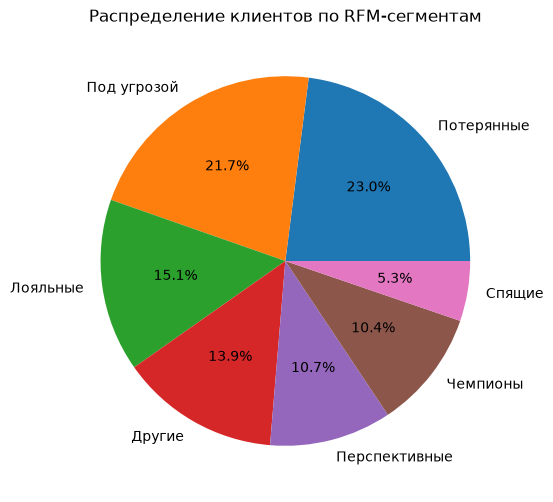

In [83]:
rfm.plot(
    kind='pie',
    y='customer_share_pct',
    labels=rfm['segment'],
    autopct='%1.1f%%',
    title='Распределение клиентов по RFM-сегментам',
    legend=False
)


RFM-сегментация выявила, что почти 44% клиентов относятся к группам риска ('Потерянные' и 'Под угрозой'), поэтому основная точка роста — их возврат через персональные акции. При этом сегмент 'Чемпионы' формирует наибольшую ценность за счет высокой частоты покупок и выручки, поэтому требует отдельной стратегии удержания.

### Бизнес-рекомендации по результатам RFM-анализа

| Сегмент           |               Стратегия на решение            |
|--------------|-----------------------------------------------|
|Чемпионы      | Программа лояльности с накопительными бонусами. Early access на новинки. Персональные подарки в день рождения.|
|Лояльные      | Программа «приведи друга» — Loyal обычно охотно рекомендуют. Кросс-селл в смежные категории.                        |
|Перспективные | Триггер на вторую покупку (скидка 10–15% на следующий заказ). Подписка на категорию интереса.                |
|Под угрозой   | Персональные предложения на основе истории покупок, напоминания о повторной покупке, бонус за возвращение              |
|Спящие        | Персональный win-back с агрессивной скидкой (20–30%).                  |
|Потерянные    |Удаление из CRM-кампаний (экономия на коммуникациях). Используем только для статистики и lookalike в платном трафике.                                               |